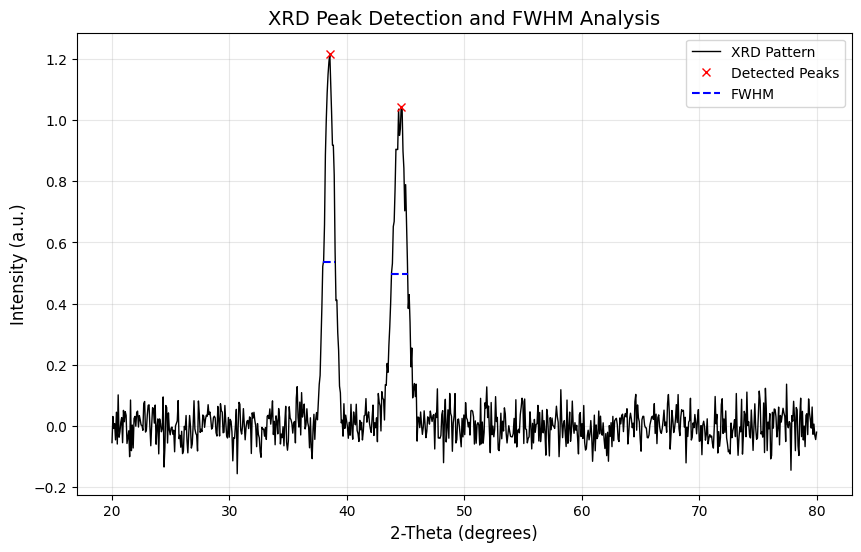

Peak 1: Position = 38.55°, FWHM = 1.0098°
Peak 2: Position = 44.63°, FWHM = 1.3758°


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# 1. Simulate XRD Data
two_theta = np.linspace(20, 80, 800)
# 建立兩個波峰：一個在 38.5度 (Al), 一個在 44.5度 (Fe)
peak1 = 1.2 * np.exp(-((two_theta - 38.5)**2) / (2 * 0.4**2))
peak2 = 1.0 * np.exp(-((two_theta - 44.5)**2) / (2 * 0.6**2))
noise = np.random.normal(0, 0.05, 800)
intensity = peak1 + peak2 + noise

# 2.Peak Finding
# height: 設定強度門檻，distance: 設定峰與峰之間的最短距離
peaks, properties = find_peaks(intensity, height=0.3, distance=20)

# 3. 計算半高寬 (Full Width at Half Maximum, FWHM)
results_half = peak_widths(intensity, peaks, rel_height=0.5)
fwhm_widths = results_half[0]  # 索引單位的寬度
h_evals = results_half[1]       # 用於畫橫線的高度
left_ips = results_half[2]      # 左側插入點
right_ips = results_half[3]     # 右側插入點

# 4. 繪圖 (Plotting)
plt.figure(figsize=(10, 6))

# 畫出原始數據線
plt.plot(two_theta, intensity, label='XRD Pattern', color='black', linewidth=1)

# 標示偵測到的峰值位置 (用紅色倒三角形)
plt.plot(two_theta[peaks], intensity[peaks], "x", color='red', label='Detected Peaks')

# 畫出半高寬 (FWHM) 的水平線
# 注意：需要將索引轉換回 2-theta 角度
step = two_theta[1] - two_theta[0]
plt.hlines(h_evals, 
           two_theta[0] + left_ips * step, 
           two_theta[0] + right_ips * step, 
           color="blue", linestyle="--", label='FWHM')

# 圖表裝飾
plt.title('XRD Peak Detection and FWHM Analysis', fontsize=14)
plt.xlabel('2-Theta (degrees)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 顯示圖表
plt.show()

# 輸出數值結果
for i, peak_idx in enumerate(peaks):
    print(f"Peak {i+1}: Position = {two_theta[peak_idx]:.2f}°, FWHM = {fwhm_widths[i]*step:.4f}°")